In [1]:
ENV["PYTHONPATH"] = "/home/gridsan/aligho/.local/lib/python3.8/site-packages/PyNormaliz-2.15-py3.8-linux-x86_64.egg";

In [5]:
using DelimitedFiles, PyPlot, LinearAlgebra
using Crystalline, Brillouin, MPBUtils, SymmetryBases
using Crystalline: TEST_αβγs, TEST_αβγ, dot, norm
topology_paper_dir = "../../TopologyPaper/"
include(topology_paper_dir * "get-freqs-symeigs.jl")
include(topology_paper_dir * "symeigs-from-io.jl");
using PyCall, JLD2
np = pyimport("numpy");

In [23]:
log_dir = "./logs/"
loaded_logs = load(log_dir * "dispersion-logs.jld2");
logsv = loaded_logs["logsv"];

In [27]:
log_dir = "./logs/"
log_dir_zoom = "../fig_dos_zoom/logs/"

loaded_logs = load(log_dir * "dispersion-logs.jld2");
logsv = loaded_logs["logsv"];

loaded_logs_zoom = load(log_dir_zoom * "dispersion-logs.jld2");
logsv_zoom = loaded_logs_zoom["logsv"];

In [29]:
dispersionv = Float64[]
dispersionv_band2 = Float64[]
kxv = Float64[]
kyv = Float64[]
kzv = Float64[]

for (id, log) in enumerate(logsv)
    (id % 2000) == 0 && (println("id: $id"); flush(stdout))
    dispersion_str = logs_to_dispersion(log, "");
    dispersion = readdlm(IOBuffer(dispersion_str), ',')[:, 6:end]
    push!(dispersionv, vec(dispersion)...)
    kpts = readdlm(IOBuffer(dispersion_str), ',')[:, 2:4];
    push!(kxv, kpts[:, 1]...)
    push!(kyv, kpts[:, 2]...)
    push!(kzv, kpts[:, 3]...)
    push!(dispersionv_band2, dispersion[:, 2]...)
end

dispersionv_zoom = Float64[]
dispersionv_band2_zoom = Float64[]
kxv_zoom = Float64[]
kyv_zoom = Float64[]
kzv_zoom = Float64[]

for (id, log) in enumerate(logsv_zoom)
    (id % 2000) == 0 && (println("id: $id"); flush(stdout))
    dispersion_str = logs_to_dispersion(log, "");
    dispersion = readdlm(IOBuffer(dispersion_str), ',')[:, 6:end]
    push!(dispersionv_zoom, vec(dispersion)...)
    kpts = readdlm(IOBuffer(dispersion_str), ',')[:, 2:4];
    push!(kxv_zoom, kpts[:, 1]...)
    push!(kyv_zoom, kpts[:, 2]...)
    push!(kzv_zoom, kpts[:, 3]...)
    push!(dispersionv_band2_zoom, dispersion[:, 2]...)
end

id: 2000
id: 4000
id: 6000
id: 8000
id: 10000
id: 2000
id: 4000
id: 6000
id: 8000
id: 10000


In [92]:
dos, energies = np.histogram(dispersionv, bins=10000)
dos_zoom, energies_zoom = np.histogram(dispersionv_zoom, bins=10000);

In [93]:
filtered_idxs_1 = np.where(abs.(dispersionv_band2 .- 0.325) .< 0.005)[1] .+ 1;
filtered_idxs_2 = np.where( 0.007 .< abs.(dispersionv_band2 .- 0.325) .< 0.01)[1] .+ 1;
filtered_idxs_3 = np.where(0.012 .< abs.(dispersionv_band2 .- 0.325) .< 0.015)[1] .+ 1;

In [95]:
window_size = 20 
dos_smoothed = np.convolve(dos, np.ones(window_size)/window_size, mode="same");

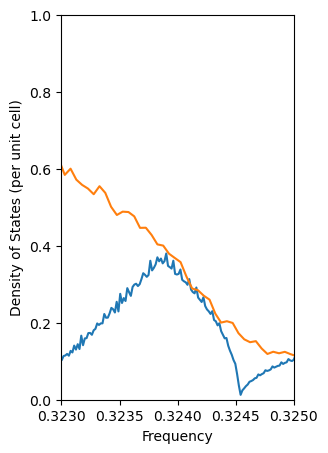

In [96]:
figure(figsize=(3, 5))
zoom_factor = 10^3
plot(energies_zoom[1:end-1], dos_zoom/length(dispersionv_zoom)/diff(energies_zoom)[1]/zoom_factor)
plot(energies[1:end-1], dos_smoothed/length(dispersionv)/diff(energies)[1])

#ylim
ylim(0, 1)
xlim(0.323, 0.325)
xlabel("Frequency")
ylabel("Density of States (per unit cell)");

# Here we try to combine the dos plots in a sensible way

In [100]:
length(dispersionv)/5

1.02e6

In [101]:
nk = length(dispersionv)/5 # number of k points is length of dispersion divided by the number of bands
nk_zoom = length(dispersionv)/5

near_degeneracy_idxs = findall(x-> 0.3238 < x < 0.325, energies_zoom[1:end-1]);
away_from_degeneracy_idxs_1 = findall(x-> 0.3238 > x , energies[1:end-1]);
away_from_degeneracy_idxs_2 = findall(x-> 0.325 < x , energies[1:end-1]);
normalized_dos = dos_smoothed/nk/diff(energies)[1]
normalized_dos_zoom = dos_zoom/nk_zoom/diff(energies_zoom)[1]/zoom_factor;

In [86]:
combined_energies = [energies[away_from_degeneracy_idxs_1]..., energies_zoom[near_degeneracy_idxs]..., energies[away_from_degeneracy_idxs_2]...];
combined_dos = [normalized_dos[away_from_degeneracy_idxs_1]..., normalized_dos_zoom[near_degeneracy_idxs]..., normalized_dos[away_from_degeneracy_idxs_2]...];

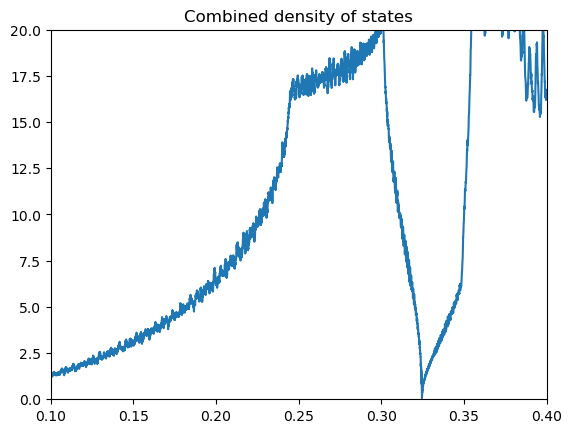

In [91]:
#scatter(energies_zoom[1:end-1][near_degeneracy_idxs], (dos_zoom/length(dispersionv_zoom)/diff(energies_zoom)[1]/zoom_factor)[near_degeneracy_idxs], s=1)
#scatter(energies[1:end-1][away_from_degeneracy_idxs], (dos_smoothed/length(dispersionv)/diff(energies)[1])[away_from_degeneracy_idxs], s=1) 
plot(combined_energies, combined_dos)
ylim(0, 20)
xlim(0.1, 0.4)
title("Combined density of states");

In [ ]:
figure(figsize=(3, 5))
zoom_factor = 10^3
plot(energies_zoom[1:end-1], dos_zoom/length(dispersionv_zoom)/diff(energies_zoom)[1]/zoom_factor)
plot(energies[1:end-1], dos_smoothed/length(dispersionv)/diff(energies)[1])

#ylim
ylim(0, 1)
xlim(0.32, 0.33)
xlabel("Frequency")
ylabel("Density of States (per unit cell)");

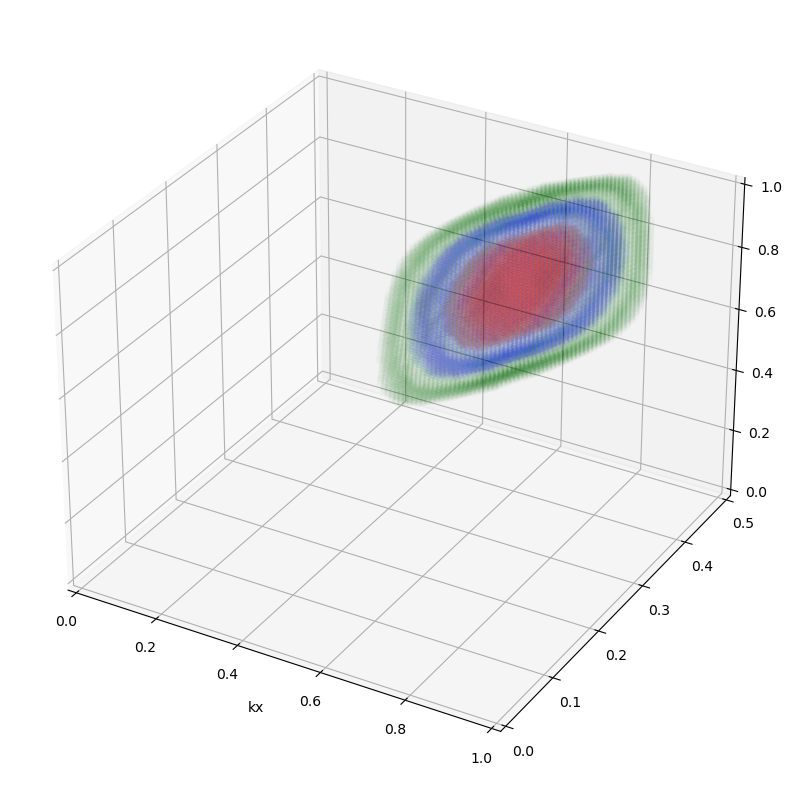

PyObject Text(-0.035854386295653934, -0.07762702342284214, 'kx')

In [45]:
figure(figsize=(10, 10))
subplot(projection="3d")
min_lim = 0
max_lim = 1
gca().scatter(mod.(kxv[filtered_idxs_1],1), mod.(kyv[filtered_idxs_1], 1), mod.(kzv[filtered_idxs_1], 1), color="red", alpha=0.01)
gca().scatter(mod.(kxv[filtered_idxs_2],1), mod.(kyv[filtered_idxs_2], 1), mod.(kzv[filtered_idxs_2], 1), color="blue", alpha=0.01)
gca().scatter(mod.(kxv[filtered_idxs_3],1), mod.(kyv[filtered_idxs_3], 1), mod.(kzv[filtered_idxs_3], 1), color="green", alpha=0.01)

#gca().plot_surface(kxv, kyv, kzv)
xlim(min_lim, max_lim)
ylim(min_lim, max_lim)
ylim(0, 0.5)
zlim(min_lim, max_lim)

xlabel("kx")


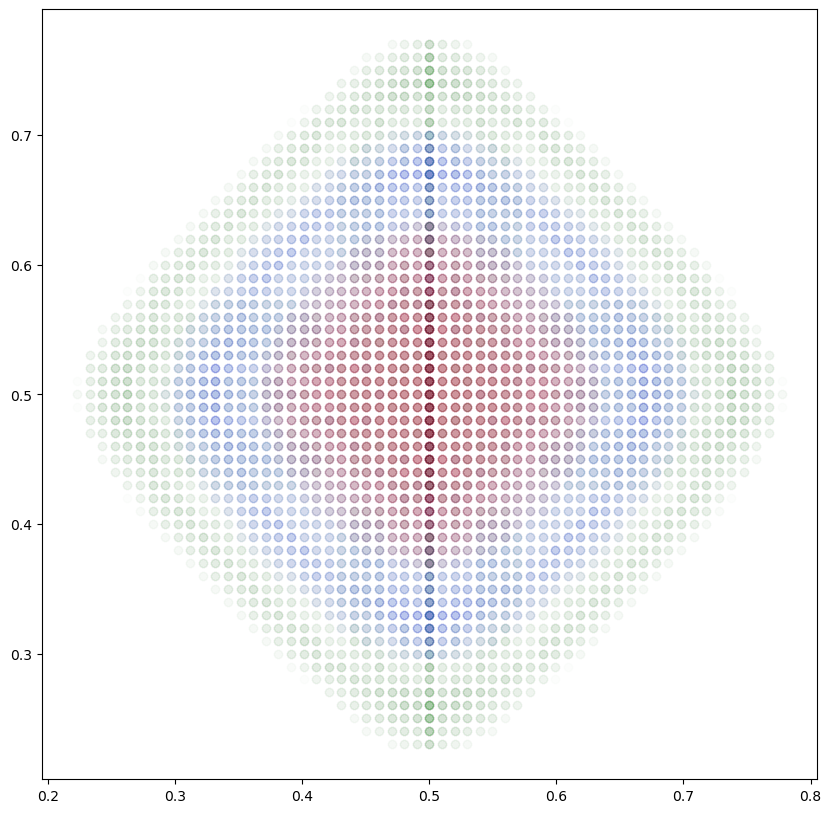

PyObject <matplotlib.collections.PathCollection object at 0x7fc09484fdf0>

In [97]:
figure(figsize=(10, 10))
subplot()
min_lim = 0
max_lim = 1
# Filter for kz value
gca().scatter(mod.(kxv[filtered_idxs_1],1), mod.(kyv[filtered_idxs_1], 1), color="red", alpha=.01)
gca().scatter(mod.(kxv[filtered_idxs_2],1), mod.(kyv[filtered_idxs_2], 1),  color="blue", alpha=.01)
gca().scatter(mod.(kxv[filtered_idxs_3],1), mod.(kyv[filtered_idxs_3], 1), color="green", alpha=.01)
